In [1]:
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
import numpy as np
import numpy
import matplotlib.pyplot as plt

In [2]:
fits.info('/user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits')

Filename: /user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1375   ()      
  1  OBJECTS       1 BinTableHDU    707   21262011R x 193C   [1J, 1J, 1J, 25A, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1I, 1I, 1I, 1I, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1D, 1D, 1I, 1J, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1J, 1J, 1J, 1J, 1J, 1E, 1J, 16A, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E,

In [3]:
data = fits.open('/user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits')[1].data

In [4]:
header = fits.open('/user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits')[1].header

In [47]:
ascii_data_1 = np.loadtxt('/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO1_Nz.asc')
ascii_data_2 = np.loadtxt('/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO2_Nz.asc')
ascii_data_3 = np.loadtxt('/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO3_Nz.asc')
ascii_data_4 = np.loadtxt('/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO4_Nz.asc')
ascii_data_5 = np.loadtxt('/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO5_Nz.asc')

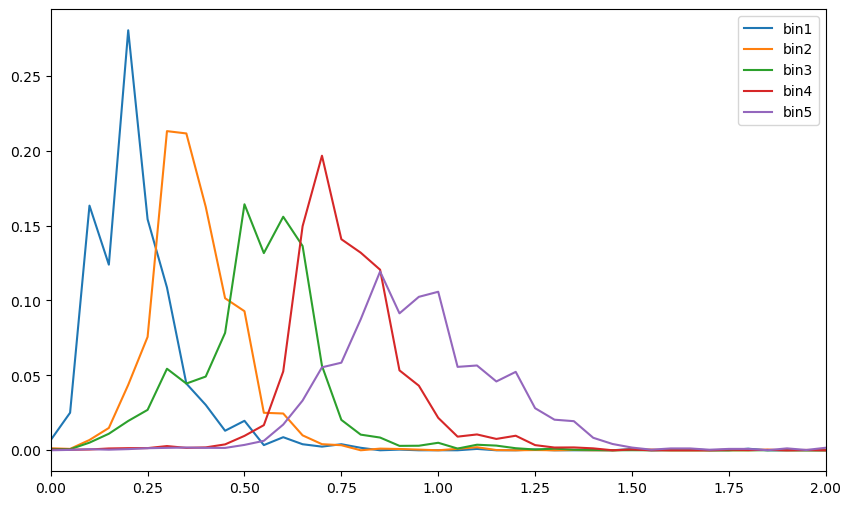

In [49]:
plt.figure(figsize = (10,6))
plt.plot(ascii_data_1[:,0], ascii_data_1[:,1], label='bin1')
plt.plot(ascii_data_2[:,0], ascii_data_2[:,1], label='bin2')
plt.plot(ascii_data_3[:,0], ascii_data_3[:,1], label='bin3')
plt.plot(ascii_data_4[:,0], ascii_data_4[:,1], label='bin4')
plt.plot(ascii_data_5[:,0], ascii_data_5[:,1], label='bin5')
plt.xlim(0,2)
plt.legend()
plt.savefig('redshift_distribution_galaxies.png')

In [51]:
area_1 = np.trapezoid(ascii_data_1[:,1], x=ascii_data_1[:,0])
area_2 = np.trapezoid(ascii_data_2[:,1], x=ascii_data_2[:,0])
area_3 = np.trapezoid(ascii_data_3[:,1], x=ascii_data_3[:,0])
area_4 = np.trapezoid(ascii_data_4[:,1], x=ascii_data_4[:,0])
area_5 = np.trapezoid(ascii_data_5[:,1], x=ascii_data_5[:,0])

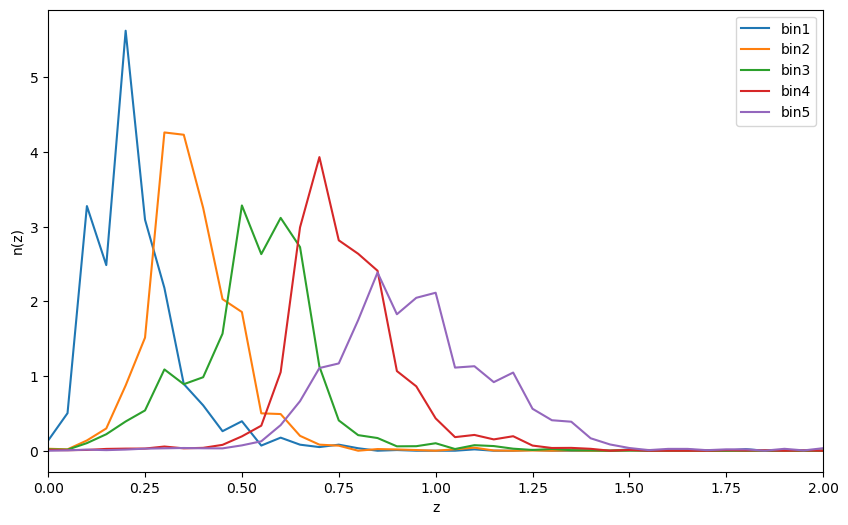

In [55]:
plt.figure(figsize = (10,6))
plt.plot(ascii_data_1[:,0], ascii_data_1[:,1]/area_1, label='bin1')
plt.plot(ascii_data_2[:,0], ascii_data_2[:,1]/area_2, label='bin2')
plt.plot(ascii_data_3[:,0], ascii_data_3[:,1]/area_3, label='bin3')
plt.plot(ascii_data_4[:,0], ascii_data_4[:,1]/area_4, label='bin4')
plt.plot(ascii_data_5[:,0], ascii_data_5[:,1]/area_5, label='bin5')
plt.xlabel('z')
plt.ylabel('n(z)')
plt.xlim(0,2)
plt.legend()
plt.savefig('redshift_distribution_galaxies_norm.png')

In [67]:
area_1_lim = np.trapezoid(ascii_data_1[:,1][(ascii_data_1[:,0] > 0.1) & (ascii_data_1[:,0] <= 0.3)], x=ascii_data_1[:,0][(ascii_data_1[:,0] > 0.1) & (ascii_data_1[:,0] <= 0.3)])
area_2_lim = np.trapezoid(ascii_data_2[:,1][(ascii_data_2[:,0] > 0.3) & (ascii_data_2[:,0] <= 0.5)], x=ascii_data_2[:,0][(ascii_data_2[:,0] > 0.3) & (ascii_data_2[:,0] <= 0.5)])
area_3_lim = np.trapezoid(ascii_data_3[:,1][(ascii_data_3[:,0] > 0.5) & (ascii_data_3[:,0] <= 0.7)], x=ascii_data_3[:,0][(ascii_data_3[:,0] > 0.5) & (ascii_data_3[:,0] <= 0.7)])
area_4_lim = np.trapezoid(ascii_data_4[:,1][(ascii_data_4[:,0] > 0.7) & (ascii_data_4[:,0] <= 0.9)], x=ascii_data_4[:,0][(ascii_data_4[:,0] > 0.7) & (ascii_data_4[:,0] <= 0.9)])
area_5_lim = np.trapezoid(ascii_data_5[:,1][(ascii_data_5[:,0] > 0.9) & (ascii_data_5[:,0] <= 1.2)], x=ascii_data_5[:,0][(ascii_data_5[:,0] > 0.9) & (ascii_data_5[:,0] <= 1.2)])

In [70]:
np.array([area_1_lim/area_1, area_2_lim/area_2, area_3_lim/area_3, area_4_lim/area_4, area_5_lim/area_5])

array([0.42078313, 0.628793  , 0.28997052, 0.51835031, 0.2922357 ])

In [17]:
import numpy as np

z = data['Z_B']
z_0p1_0p3 = np.count_nonzero((z > 0.1) & (z <= 0.3))

z = data['Z_B']
z_0p3_0p5 = np.count_nonzero((z > 0.3) & (z <= 0.5))

z = data['Z_B']
z_0p5_0p7 = np.count_nonzero((z > 0.5) & (z <= 0.7))

z = data['Z_B']
z_0p7_0p9 = np.count_nonzero((z > 0.7) & (z <= 0.9))

z = data['Z_B']
z_0p9_1p2 = np.count_nonzero((z > 0.9) & (z <= 1.2))

print('galaxies in 0.1 - 0.3 =',z_0p1_0p3)
print('galaxies in 0.3 - 0.5 =',z_0p3_0p5)
print('galaxies in 0.5 - 0.7 =',z_0p5_0p7)
print('galaxies in 0.7 - 0.9 =',z_0p7_0p9)
print('galaxies in 0.9 - 1.2 =',z_0p9_1p2)

galaxies in 0.1 - 0.3 = 1792136
galaxies in 0.3 - 0.5 = 3681319
galaxies in 0.5 - 0.7 = 6148102
galaxies in 0.7 - 0.9 = 4544395
galaxies in 0.9 - 1.2 = 5096059


In [28]:
z = data['Z_B']
w = data['weight']

In [31]:
w_bin_1 = w[(z>0.1)&(z<=0.3)]
w_bin_2 = w[(z>0.3)&(z<=0.5)]
w_bin_3 = w[(z>0.5)&(z<=0.7)]
w_bin_4 = w[(z>0.7)&(z<=0.9)]
w_bin_5 = w[(z>0.9)&(z<=1.2)]

In [58]:
# neff_1 = (np.sum(w_bin_1)**2/np.sum(x**2 for x in w_bin_1))/(777.4*3600)
# neff_2 = (np.sum(w_bin_2)**2/np.sum(x**2 for x in w_bin_2))/(777.4*3600)
# neff_3 = (np.sum(w_bin_3)**2/np.sum(x**2 for x in w_bin_3))/(777.4*3600)
# neff_4 = (np.sum(w_bin_4)**2/np.sum(x**2 for x in w_bin_4))/(777.4*3600)
# neff_5 = (np.sum(w_bin_5)**2/np.sum(x**2 for x in w_bin_5))/(777.4*3600)

In [59]:
area = 777.4 * 3600

def neff(weights):
    weights = np.asarray(weights)
    return np.square(weights.sum()) / np.square(weights).sum() / area

neff_1 = neff(w_bin_1)
neff_2 = neff(w_bin_2)
neff_3 = neff(w_bin_3)
neff_4 = neff(w_bin_4)
neff_5 = neff(w_bin_5)

In [60]:
print('neff 0.1 - 0.3 =', neff_1)
print('neff 0.3 - 0.5 =', neff_2)
print('neff 0.5 - 0.7 =', neff_3)
print('neff 0.7 - 0.9 =', neff_4)
print('neff 0.9 - 1.2 =', neff_5)

neff 0.1 - 0.3 = 0.61638045
neff 0.3 - 0.5 = 1.1821318
neff 0.5 - 0.7 = 1.8541157
neff 0.7 - 0.9 = 1.259205
neff 0.9 - 1.2 = 1.3108857


In [48]:
z

array([0.71, 0.44, 1.08, ..., 0.46, 0.52, 0.62],
      shape=(21262011,), dtype='>f8')

In [49]:
w

array([ 0.7116, 15.5395, 14.4574, ..., 15.4484, 15.0339,  7.0869],
      shape=(21262011,), dtype='>f4')

TreeCorr

In [5]:
import treecorr
cat = treecorr.Catalog('/user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits', ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees',
                       g1_col='e1', g2_col='e2')
gg = treecorr.GGCorrelation(min_sep=1., max_sep=100., bin_size=0.1,
                            sep_units='arcmin')
gg.process(cat)
xip = gg.xip  # The xi_plus correlation function
xim = gg.xim  # The xi_minus correlation function
# gg.write('gg.out')

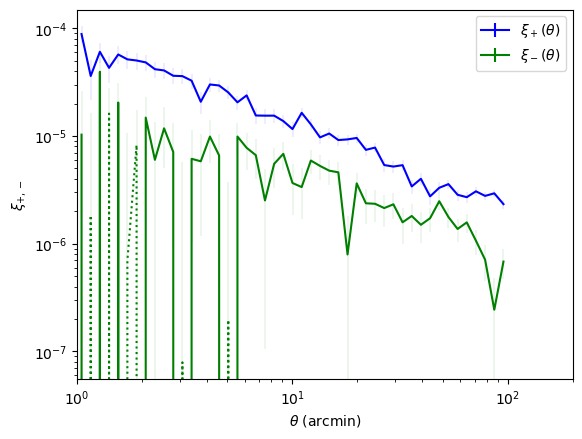

In [6]:
r = numpy.exp(gg.meanlogr)
xip = gg.xip
xim = gg.xim
sig = numpy.sqrt(gg.varxip)

plt.plot(r, xip, color='blue')
plt.plot(r, -xip, color='blue', ls=':')
plt.errorbar(r[xip>0], xip[xip>0], yerr=sig[xip>0], color='blue', lw=0.1, ls='')
plt.errorbar(r[xip<0], -xip[xip<0], yerr=sig[xip<0], color='blue', lw=0.1, ls='')
lp = plt.errorbar(-r, xip, yerr=sig, color='blue')

plt.plot(r, xim, color='green')
plt.plot(r, -xim, color='green', ls=':')
plt.errorbar(r[xim>0], xim[xim>0], yerr=sig[xim>0], color='green', lw=0.1, ls='')
plt.errorbar(r[xim<0], -xim[xim<0], yerr=sig[xim<0], color='green', lw=0.1, ls='')
lm = plt.errorbar(-r, xim, yerr=sig, color='green')

plt.xscale('log')
plt.yscale('log', nonpositive='clip')
plt.xlabel(r'$\theta$ (arcmin)')

plt.legend([lp, lm], [r'$\xi_+(\theta)$', r'$\xi_-(\theta)$'])
plt.xlim( [1,200] )
plt.ylabel(r'$\xi_{+,-}$')
plt.show()

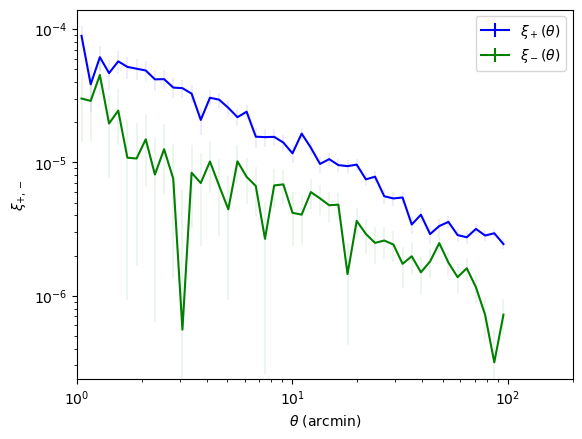

In [7]:
r = numpy.exp(gg.meanlogr)
xip = gg.xip
xim = gg.xim
xip_im = gg.xip_im
xim_im = gg.xim_im
sig = numpy.sqrt(gg.varxip)

plt.plot(r, np.sqrt(xip**2 + xip_im**2), color='blue')
# plt.plot(r, -xip, color='blue', ls=':')
plt.errorbar(r, np.sqrt(xip**2 + xip_im**2), yerr=sig, color='blue', lw=0.1, ls='')
# plt.errorbar(r[xip<0], -xip[xip<0], yerr=sig[xip<0], color='blue', lw=0.1, ls='')
# lp = plt.errorbar(-r, xip, yerr=sig, color='blue')

plt.plot(r, np.sqrt(xim**2 + xim_im**2), color='green')
# plt.plot(r, -xip, color='blue', ls=':')
plt.errorbar(r, np.sqrt(xim**2 + xim_im**2), yerr=sig, color='green', lw=0.1, ls='')


plt.xscale('log')
plt.yscale('log', nonpositive='clip')
plt.xlabel(r'$\theta$ (arcmin)')

plt.legend([lp, lm], [r'$\xi_+(\theta)$', r'$\xi_-(\theta)$'])
plt.xlim( [1,200] )
plt.ylabel(r'$\xi_{+,-}$')
plt.show()

In [8]:
z = data['Z_B']

mask1 = (z > 0.1) & (z <= 0.3)
mask2 = (z > 0.3) & (z <= 0.5)
mask3 = (z > 0.5) & (z <= 0.7)
mask4 = (z > 0.7) & (z <= 0.9)
mask5 = (z > 0.9) & (z <= 1.2)

In [9]:
# treecorr.Catalog?

In [10]:
cat1 = treecorr.Catalog(
    ra=data['RAJ2000'][mask1],
    dec=data['DECJ2000'][mask1],
    g1=data['e1'][mask1],
    g2=data['e2'][mask1],
    w=data['weight'][mask1],
    ra_units='deg',
    dec_units='deg'
)

cat2 = treecorr.Catalog(
    ra=data['RAJ2000'][mask2],
    dec=data['DECJ2000'][mask2],
    g1=data['e1'][mask2],
    g2=data['e2'][mask2],
    w=data['weight'][mask2],
    ra_units='deg',
    dec_units='deg'
)

cat3 = treecorr.Catalog(
    ra=data['RAJ2000'][mask3],
    dec=data['DECJ2000'][mask3],
    g1=data['e1'][mask3],
    g2=data['e2'][mask3],
    w=data['weight'][mask3],
    ra_units='deg',
    dec_units='deg'
)

cat4 = treecorr.Catalog(
    ra=data['RAJ2000'][mask4],
    dec=data['DECJ2000'][mask4],
    g1=data['e1'][mask4],
    g2=data['e2'][mask4],
    w=data['weight'][mask4],
    ra_units='deg',
    dec_units='deg'
)

cat5 = treecorr.Catalog(
    ra=data['RAJ2000'][mask5],
    dec=data['DECJ2000'][mask5],
    g1=data['e1'][mask5],
    g2=data['e2'][mask5],
    w=data['weight'][mask5],
    ra_units='deg',
    dec_units='deg'
)

In [90]:
cat1

treecorr.Catalog(ra=array([2.24442188, 2.26399751, 2.26398868, ..., 0.1205097 , 0.11999495,
       0.11967936], shape=(1792136,)),ra_units='rad',dec=array([-0.02156435,  0.03733802,  0.03783926, ..., -0.58713869,
       -0.58705146, -0.5870505 ], shape=(1792136,)),dec_units='rad',w=array([15.56289959, 15.24069977, 15.56289959, ..., 14.70510006,
       14.67730045, 15.56289959], shape=(1792136,)),g1=array([ 0.32139999,  0.1002    ,  0.2       , ...,  0.0479    ,
        0.0473    , -0.2352    ], shape=(1792136,)),g2=array([-0.4276    ,  0.2502    , -0.12      , ..., -0.0536    ,
        0.70899999,  0.53920001], shape=(1792136,)))

In [37]:
# Auto-correlations
gg11 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg11.process(cat1)

gg22 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg22.process(cat2)

gg33 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg33.process(cat3)

gg44 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg44.process(cat4)

gg55 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg55.process(cat5)

# Cross-correlations
gg12 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg12.process(cat1, cat2)

gg13 = treecorr.GGCorrelation(min_sep=0.1, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg13.process(cat1, cat3)

gg14 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg14.process(cat1, cat4)

gg15 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg15.process(cat1, cat5)

gg23 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg23.process(cat2, cat3)

gg24 = treecorr.GGCorrelation(min_sep=0.1, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg24.process(cat2, cat4)

gg25 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg25.process(cat2, cat5)

gg34 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg34.process(cat3, cat4)

gg35 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg35.process(cat3, cat5)

gg45 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg45.process(cat4, cat5)

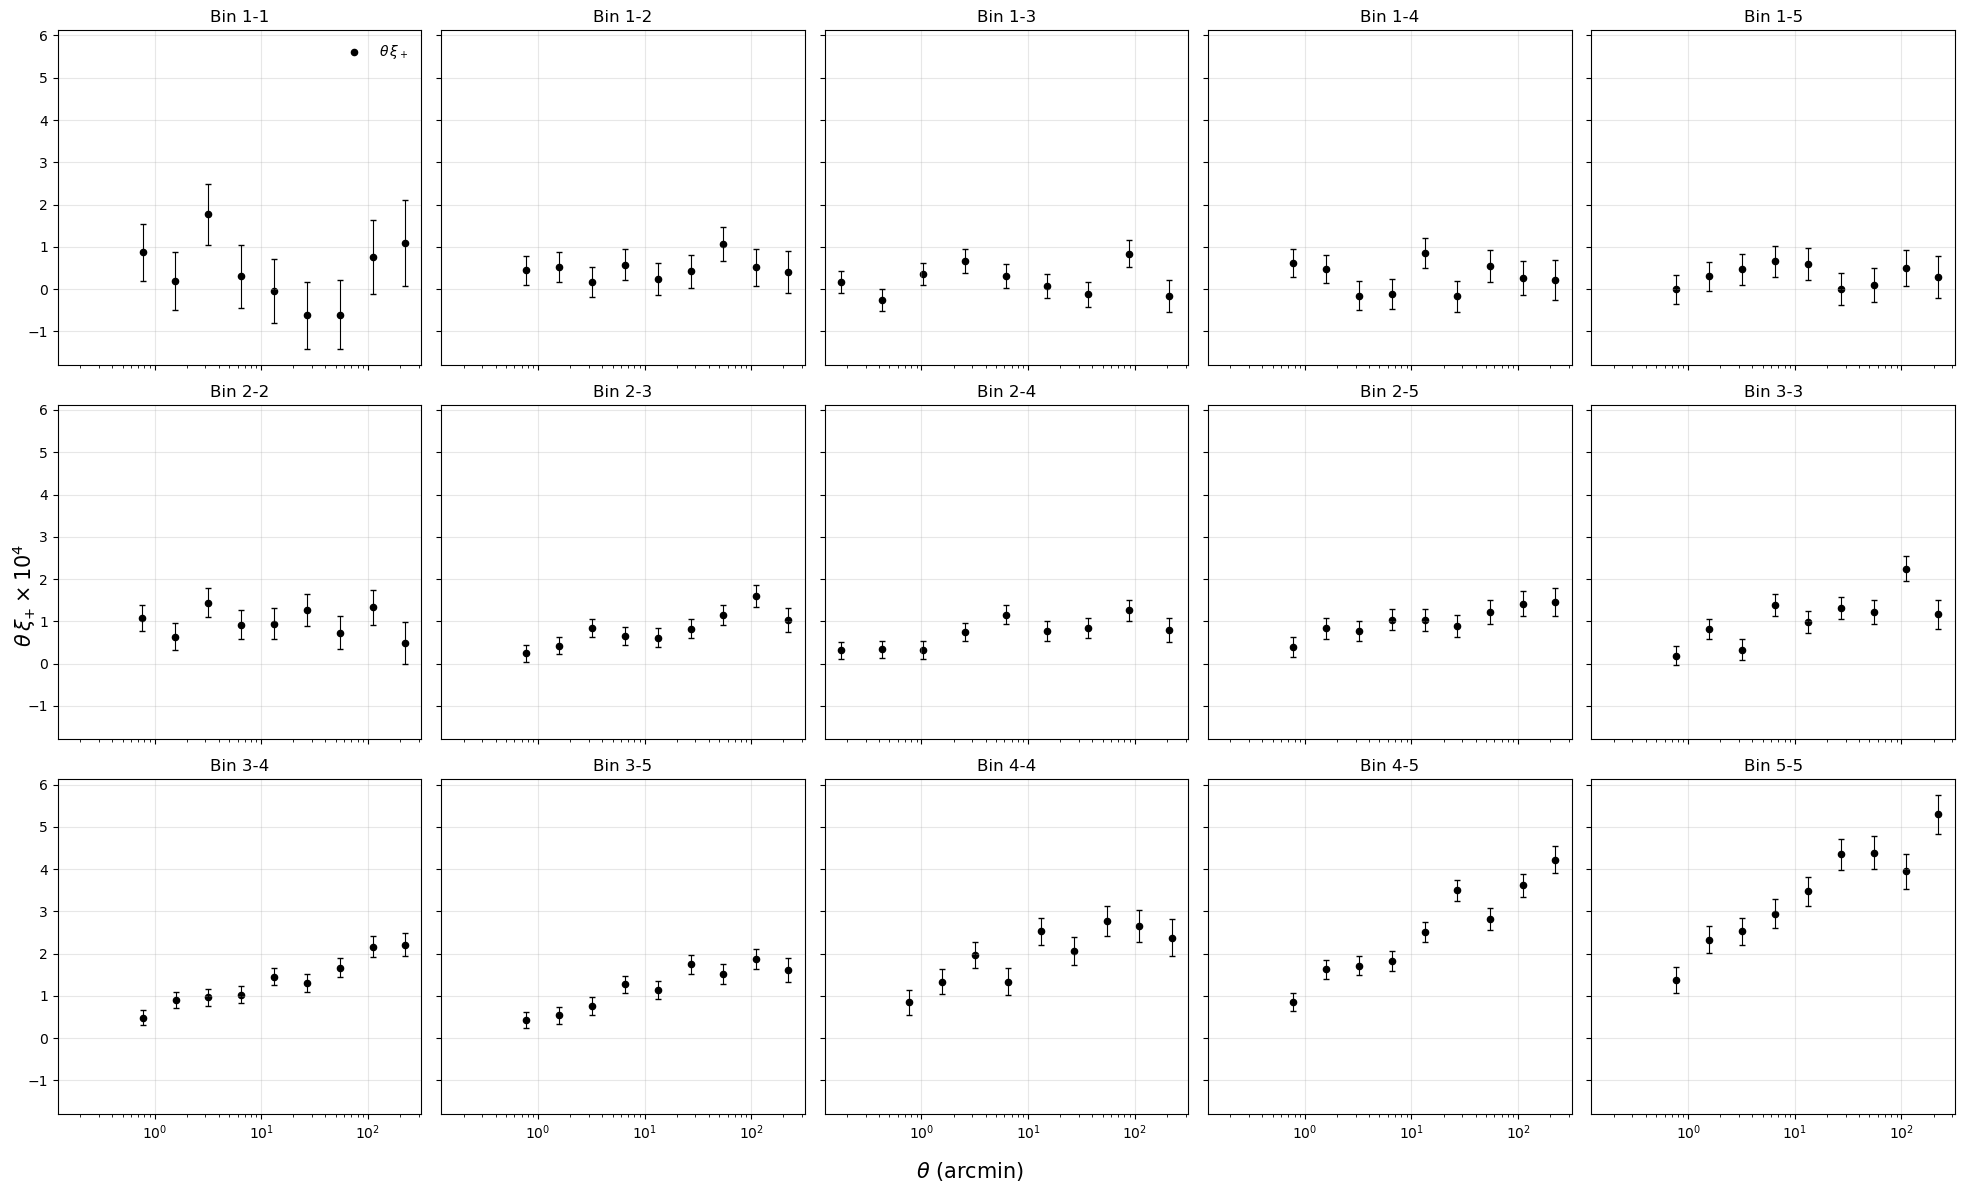

In [38]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

scale = 1e4

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, gg, lab) in enumerate(zip(axes, ggs, labels)):

    r = np.exp(gg.meanlogr)

    xip = scale * gg.xip
    sig = scale * np.sqrt(gg.varxip)

    # Scatter points
    ax.scatter(
        r, r * xip,
        color='black',
        s=20,
        marker='o',
        label=r'$\theta\,\xi_+$' if i == 0 else None
    )

    # Error bars
    ax.errorbar(
        r, r * xip,
        yerr=r * sig,
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    ax.set_xscale('log')
    # ax.set_xlim(1, 200)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{+}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('xip.png')
plt.show()

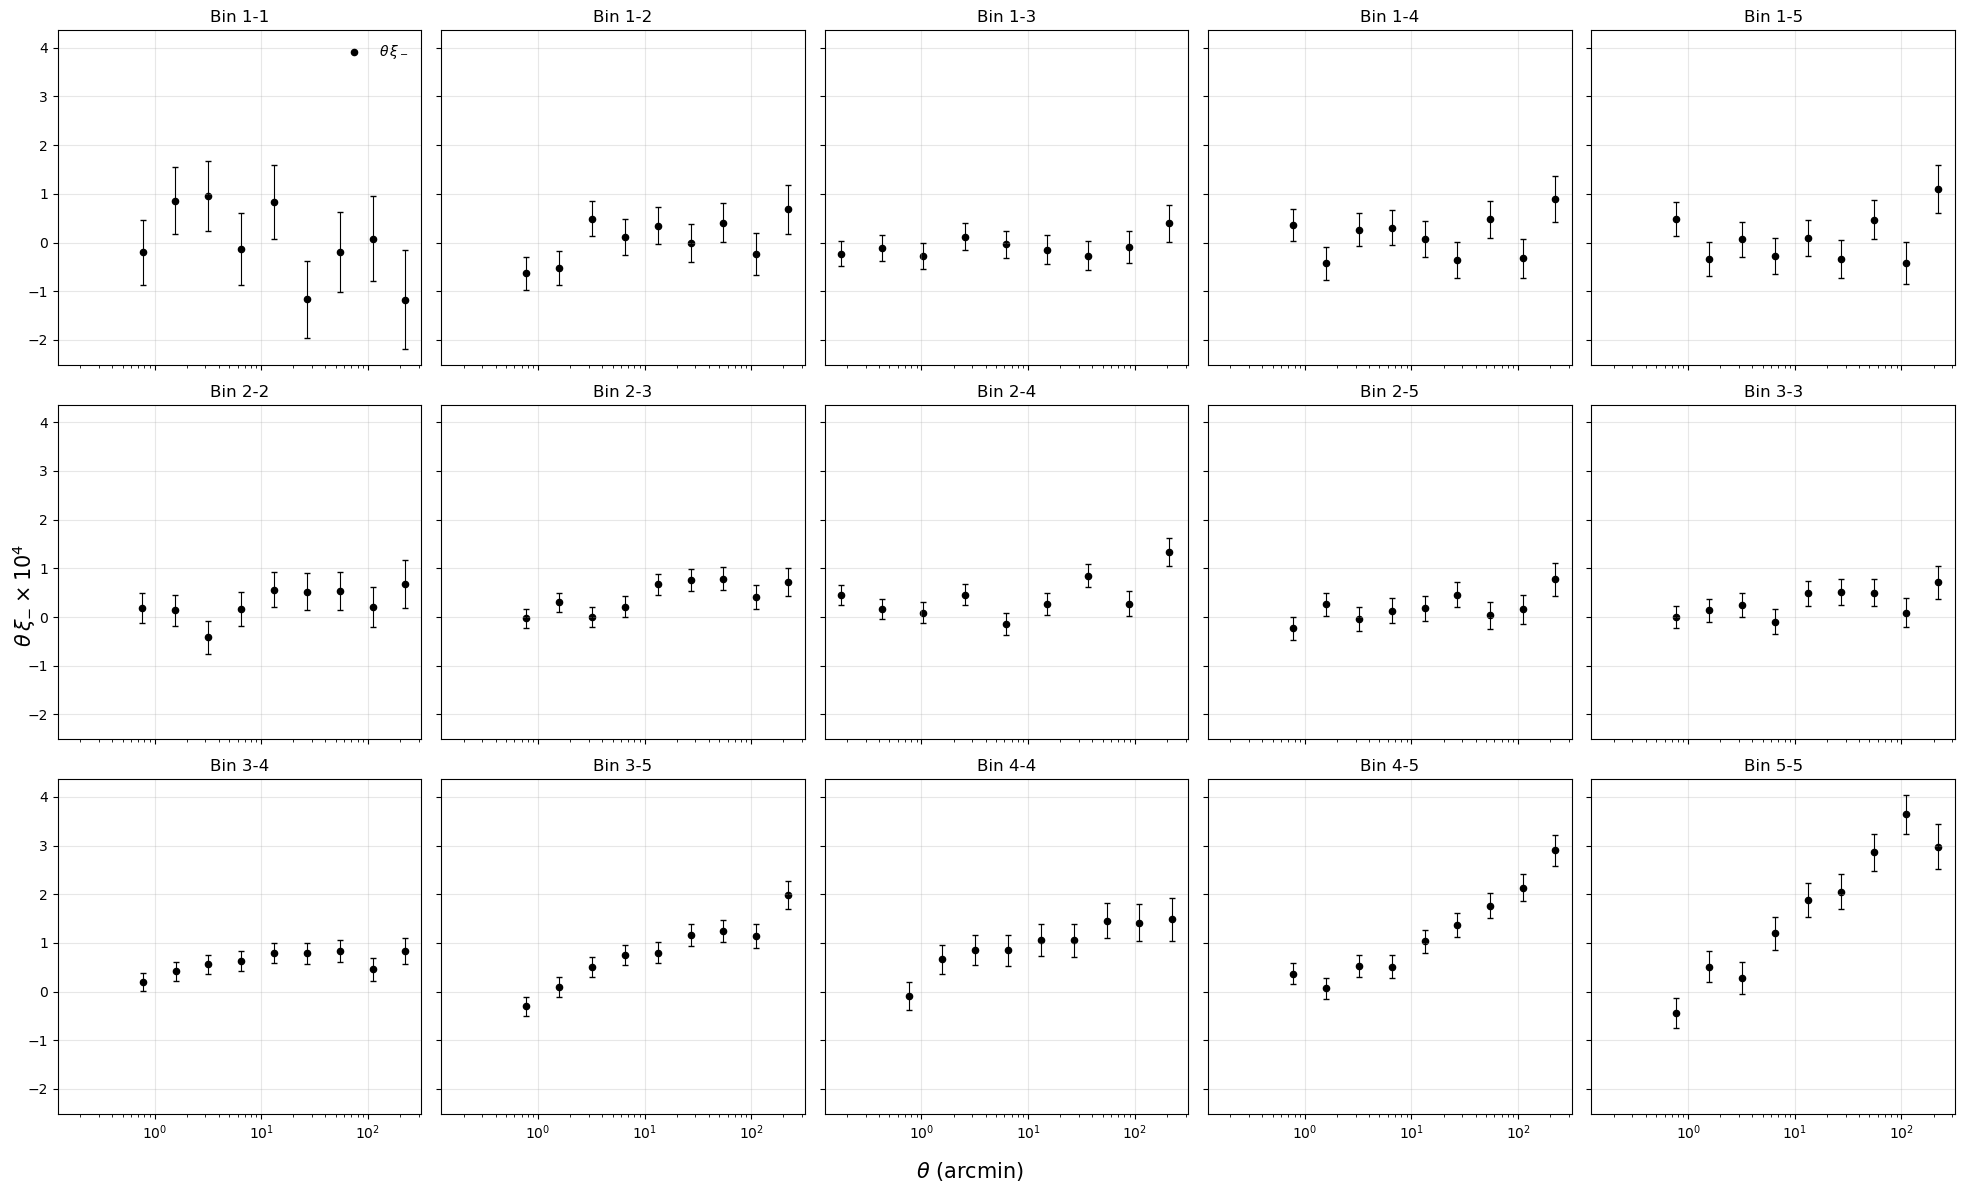

In [39]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

scale = 1e4

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, gg, lab) in enumerate(zip(axes, ggs, labels)):

    r = np.exp(gg.meanlogr)

    xim = scale * gg.xim
    sig = scale * np.sqrt(gg.varxip)

    # Scatter points
    ax.scatter(
        r, r * xim,
        color='black',
        s=20,
        marker='o',
        label=r'$\theta\,\xi_-$' if i == 0 else None
    )

    # Error bars
    ax.errorbar(
        r, r * xim,
        yerr=r * sig,
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    ax.set_xscale('log')
    # ax.set_xlim(1, 200)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{-}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('xim.png')
plt.show()

In [13]:
data_ref_xip = fits.open('/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits')[2].data

In [19]:
heder_ref_xip = fits.open('/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits')[2].header

In [15]:
fits.info('/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits')

Filename: /user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        13   (270, 270)   float64   
  2  xiP           1 BinTableHDU     29   135R x 5C   [K, K, K, D, D]   
  3  xiM           1 BinTableHDU     29   135R x 5C   [K, K, K, D, D]   
  4  NZ_SOURCE     1 BinTableHDU     36   119R x 8C   [D, D, D, D, D, D, D, D]   


In [30]:
data_ref_xim = fits.open('/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits')[3].data

In [96]:
data_ref_xip['ANG']

array([  0.71336491,   1.45209561,   2.95582478,   6.01675264,
        12.24744871,  24.93039168,  50.74725716, 103.29898312,
       210.27106705,   0.71336491,   1.45209561,   2.95582478,
         6.01675264,  12.24744871,  24.93039168,  50.74725716,
       103.29898312, 210.27106705,   0.71336491,   1.45209561,
         2.95582478,   6.01675264,  12.24744871,  24.93039168,
        50.74725716, 103.29898312, 210.27106705,   0.71336491,
         1.45209561,   2.95582478,   6.01675264,  12.24744871,
        24.93039168,  50.74725716, 103.29898312, 210.27106705,
         0.71336491,   1.45209561,   2.95582478,   6.01675264,
        12.24744871,  24.93039168,  50.74725716, 103.29898312,
       210.27106705,   0.71336491,   1.45209561,   2.95582478,
         6.01675264,  12.24744871,  24.93039168,  50.74725716,
       103.29898312, 210.27106705,   0.71336491,   1.45209561,
         2.95582478,   6.01675264,  12.24744871,  24.93039168,
        50.74725716, 103.29898312, 210.27106705,   0.71

In [22]:
m_1, m_2, m_3, m_4, m_5 = -0.009, -0.011, -0.015, 0.002, 0.007

/tmp/ipykernel_4055994/3368831502.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-2.5, 200)


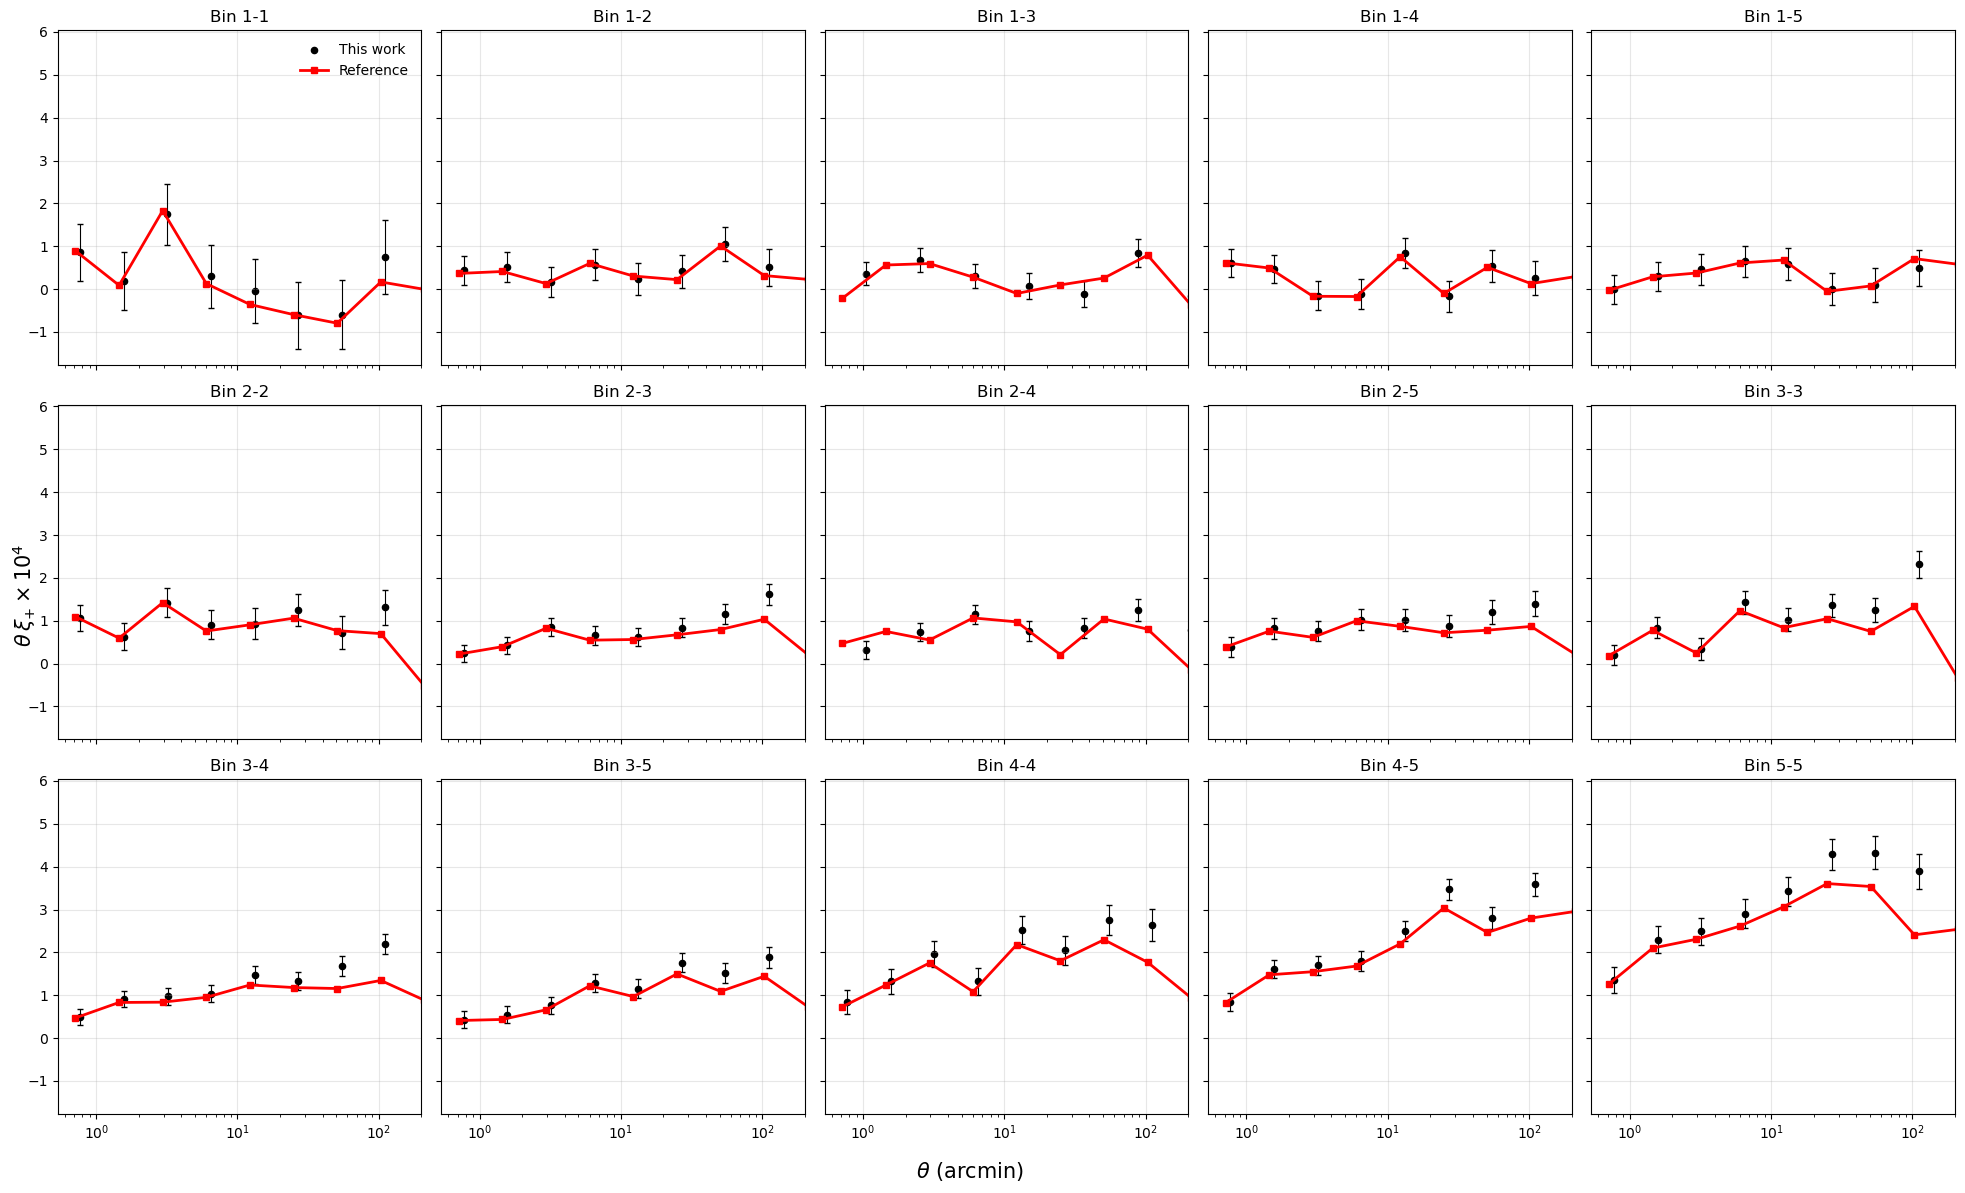

In [43]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

bin_pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

m_pairs = [
    (m_1,m_1), (m_1,m_2), (m_1,m_3), (m_1,m_4), (m_1,m_5),
    (m_2,m_2), (m_2,m_3), (m_2,m_4), (m_2,m_5),
    (m_3,m_3), (m_3,m_4), (m_3,m_5),
    (m_4,m_4), (m_4,m_5),
    (m_5,m_5)
]

scale = 1e4

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, gg, lab, (b1, b2), (m_1, m_2)) in enumerate(zip(axes, ggs, labels, bin_pairs, m_pairs)):

    # Your measurements
    r = np.exp(gg.meanlogr)
    xip = scale * gg.xip
    sig = scale * np.sqrt(gg.varxip)

    ax.scatter(
        r, r * xip/((1+m_1)*(1+m_2)),
        color='black',
        s=20,
        marker='o',
        label='This work' if i == 0 else None
    )

    ax.errorbar(
        r, r * xip/((1+m_1)*(1+m_2)),
        yerr=r * sig/((1+m_1)*(1+m_2)),
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    # Reference data
    ref = data_ref_xip[
        (data_ref_xip['BIN1'] == b1) &
        (data_ref_xip['BIN2'] == b2)
    ]

    ax.plot(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        color='red',
        lw=2,
        marker='s',
        ms=4,
        label='Reference' if i == 0 else None
    )

    ax.set_xscale('log')
    ax.set_xlim(-2.5, 200)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{+}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("xip_comparison.png", dpi=300)
plt.show()

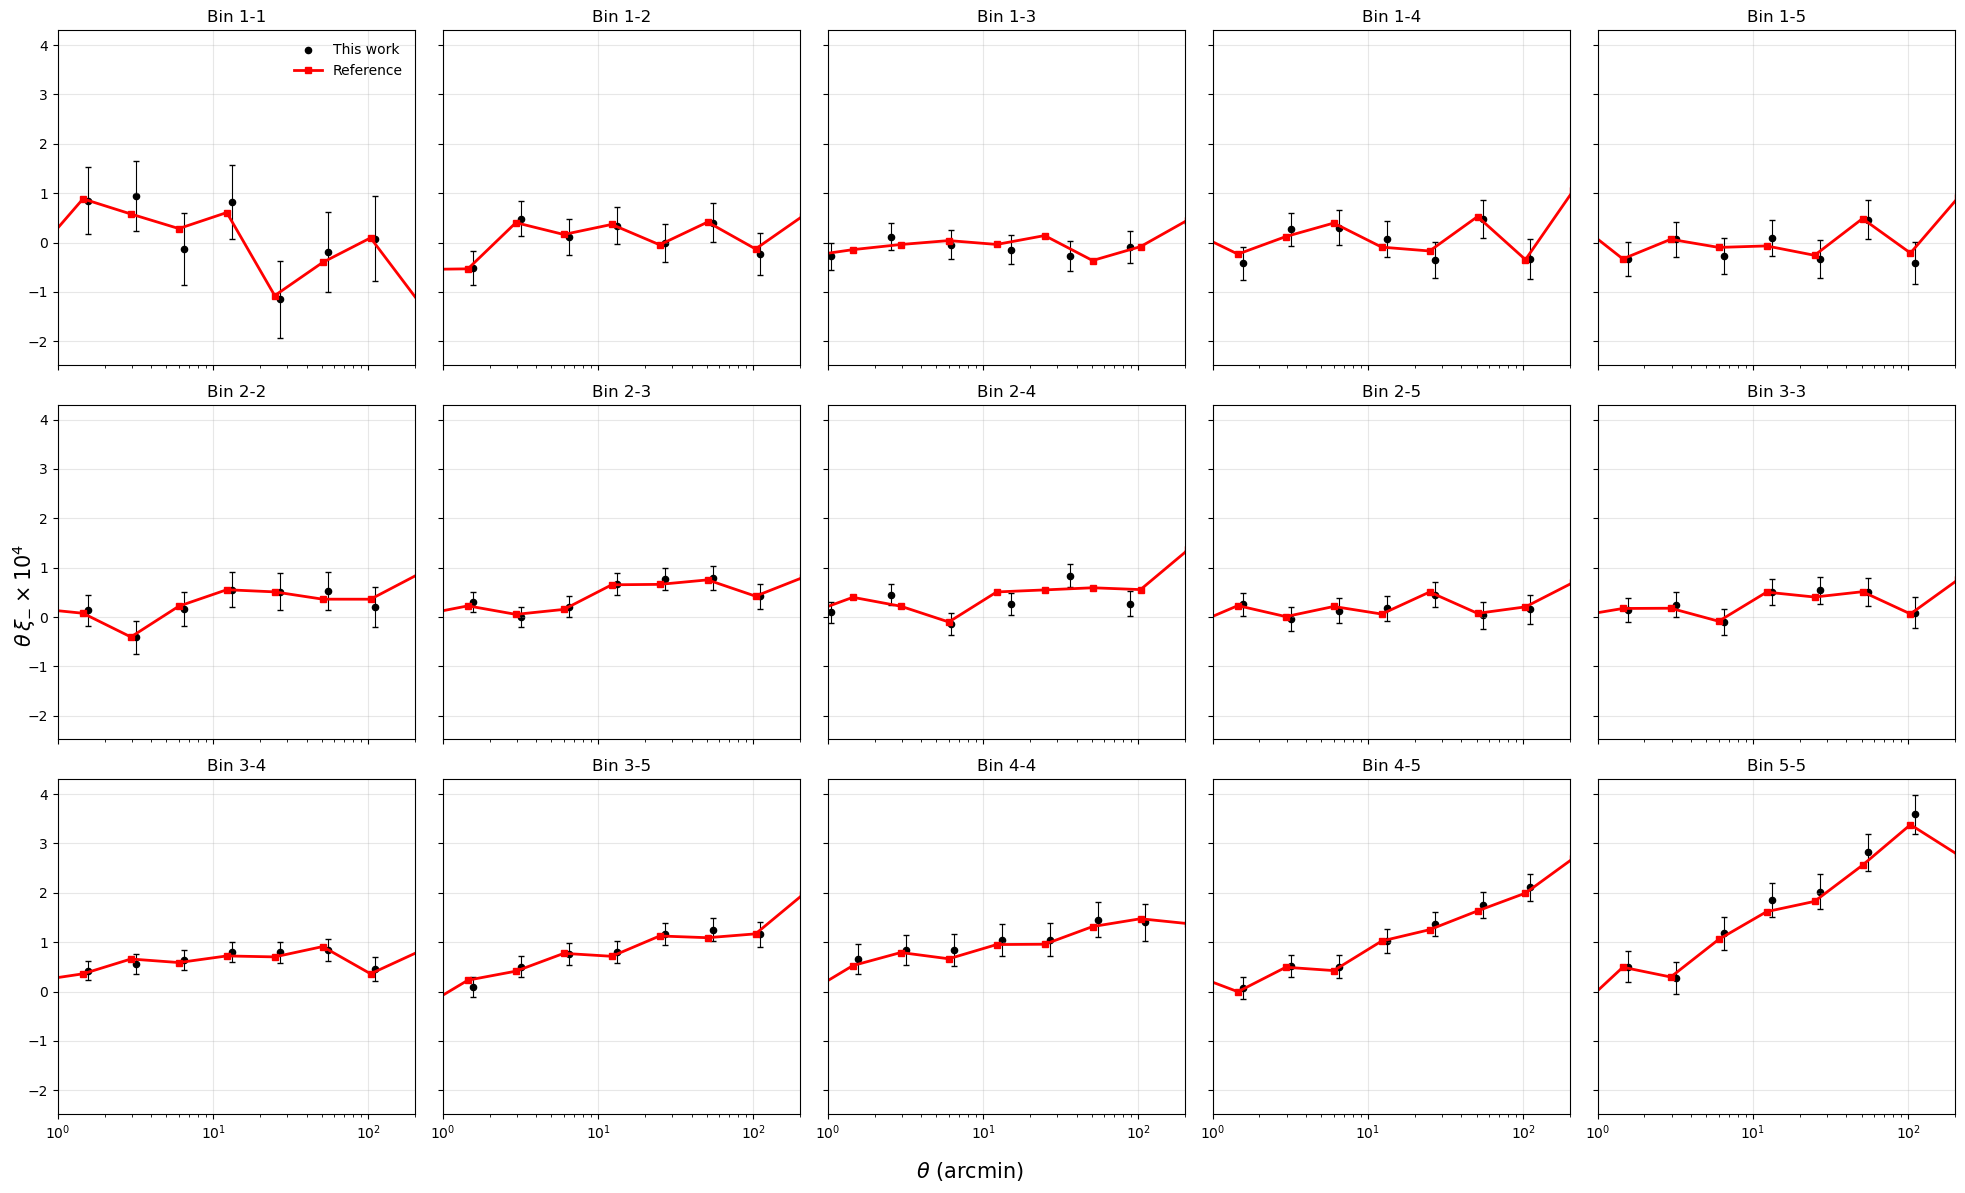

In [41]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

bin_pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

m_pairs = [
    (m_1,m_1), (m_1,m_2), (m_1,m_3), (m_1,m_4), (m_1,m_5),
    (m_2,m_2), (m_2,m_3), (m_2,m_4), (m_2,m_5),
    (m_3,m_3), (m_3,m_4), (m_3,m_5),
    (m_4,m_4), (m_4,m_5),
    (m_5,m_5)
]

scale = 1e4

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, gg, lab, (b1, b2), (m_1, m_2)) in enumerate(zip(axes, ggs, labels, bin_pairs, m_pairs)):

    # Your measurements
    r = np.exp(gg.meanlogr)
    xim = scale * gg.xim
    sig = scale * np.sqrt(gg.varxim)

    ax.scatter(
        r, r * xim/((1+m_1)*(1+m_2)),
        color='black',
        s=20,
        marker='o',
        label='This work' if i == 0 else None
    )

    ax.errorbar(
        r, r * xim/((1+m_1)*(1+m_2)),
        yerr=r * sig/((1+m_1)*(1+m_2)),
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    # Reference data
    ref = data_ref_xim[
        (data_ref_xim['BIN1'] == b1) &
        (data_ref_xim['BIN2'] == b2)
    ]

    ax.plot(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        color='red',
        lw=2,
        marker='s',
        ms=4,
        label='Reference' if i == 0 else None
    )

    ax.set_xscale('log')
    ax.set_xlim(1, 200)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{-}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("xip_comparison.png", dpi=300)
plt.show()

In [44]:
data_cov = fits.open('/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits')[1].data

In [80]:
ref_errors_xip = np.diag(data_cov)[:135]

In [81]:
ref_errors_xim = np.diag(data_cov)[135:]

/tmp/ipykernel_4055994/1049743231.py:109: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-2.5, 200)


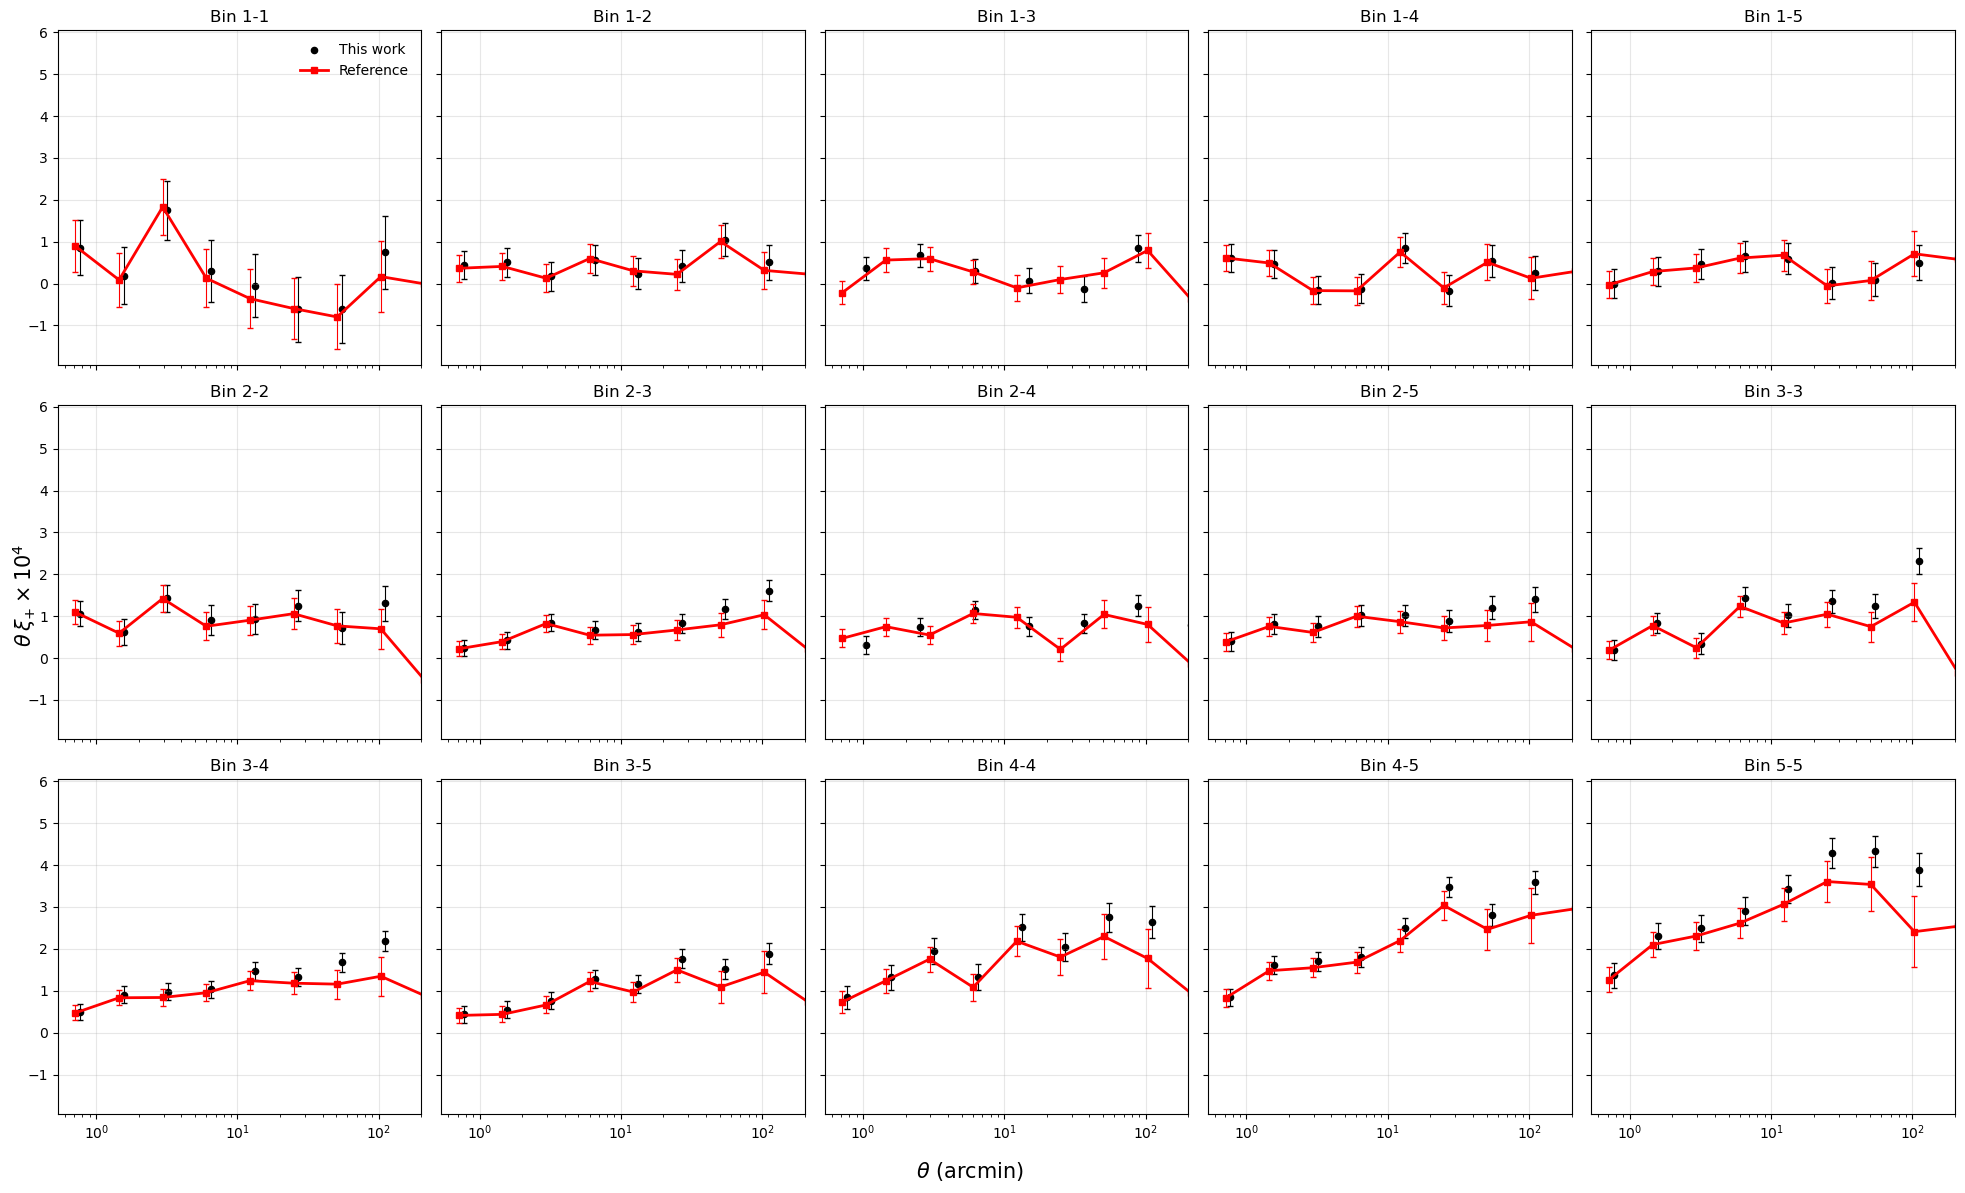

In [87]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

bin_pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

m_pairs = [
    (m_1,m_1), (m_1,m_2), (m_1,m_3), (m_1,m_4), (m_1,m_5),
    (m_2,m_2), (m_2,m_3), (m_2,m_4), (m_2,m_5),
    (m_3,m_3), (m_3,m_4), (m_3,m_5),
    (m_4,m_4), (m_4,m_5),
    (m_5,m_5)
]

scale = 1e4
n_theta = 9

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for c, (ax, gg, lab, (b1, b2), (m1, m2)) in enumerate(
    zip(axes, ggs, labels, bin_pairs, m_pairs)
):


    m_corr = (1.0 + m1) * (1.0 + m2)


    r = np.exp(gg.meanlogr)

    xip = scale * gg.xip / m_corr
    sig = scale * np.sqrt(gg.varxip) / m_corr

    ax.scatter(
        r,
        r * xip,
        color='black',
        s=20,
        marker='o',
        label='This work' if c == 0 else None
    )

    ax.errorbar(
        r,
        r * xip,
        yerr=r * sig,
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )


    ref = data_ref_xip[
        (data_ref_xip['BIN1'] == b1) &
        (data_ref_xip['BIN2'] == b2)
    ]

    start = c * n_theta
    end = (c + 1) * n_theta

    ref_err = np.sqrt(ref_errors_xip[start:end])

    ax.plot(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        color='red',
        lw=2,
        marker='s',
        ms=4,
        label='Reference' if c == 0 else None
    )

    ax.errorbar(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        yerr=scale * ref['ANG'] * ref_err,
        fmt='none',
        ecolor='red',
        elinewidth=0.8,
        capsize=2
    )

    ax.set_xscale('log')
    ax.set_xlim(-2.5, 200)
    # ax.set_ylim(-4, 4)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{+}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("xip_comparison.png", dpi=300)
plt.show()

/tmp/ipykernel_4055994/3255915390.py:109: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-2.5, 200)


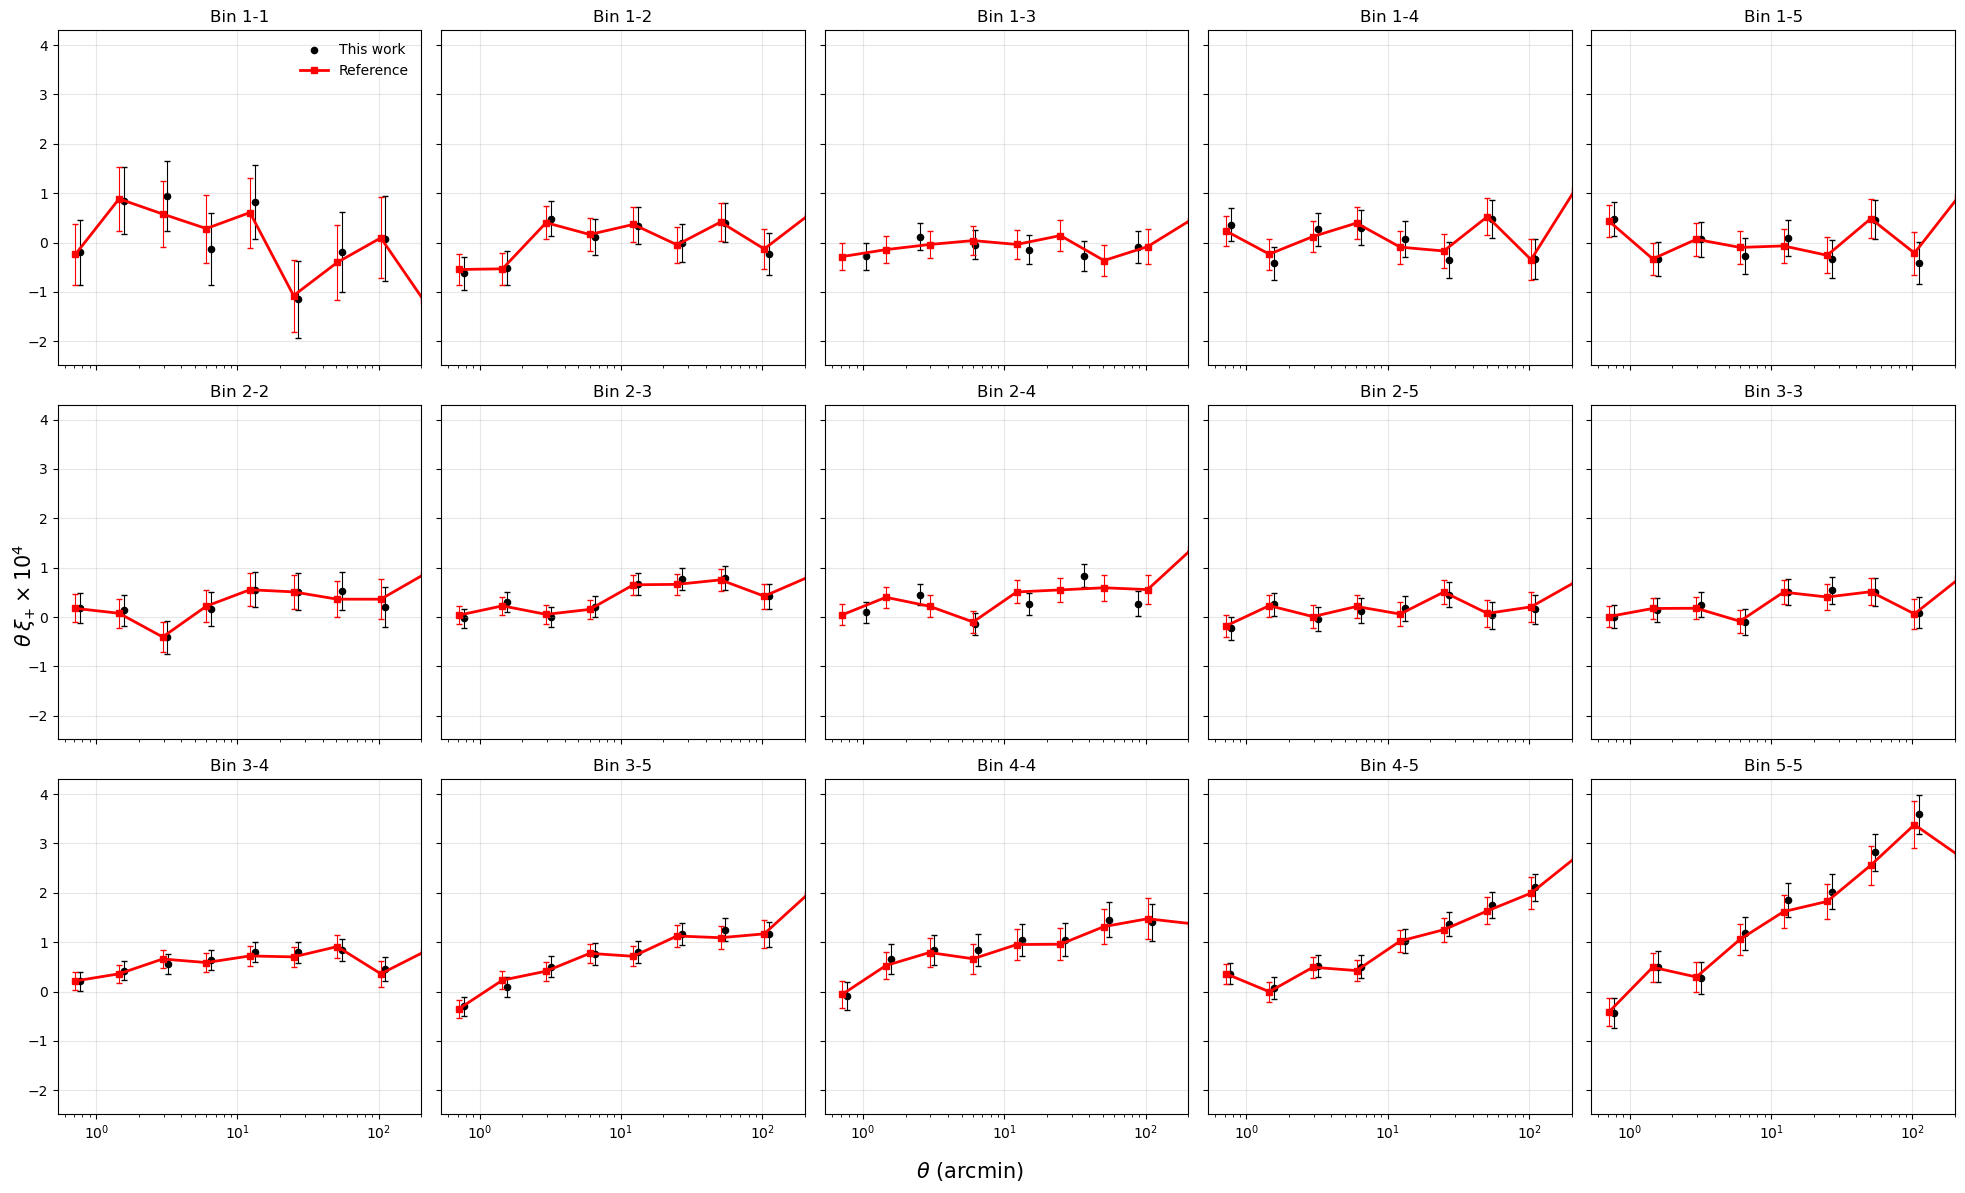

In [88]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

bin_pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

m_pairs = [
    (m_1,m_1), (m_1,m_2), (m_1,m_3), (m_1,m_4), (m_1,m_5),
    (m_2,m_2), (m_2,m_3), (m_2,m_4), (m_2,m_5),
    (m_3,m_3), (m_3,m_4), (m_3,m_5),
    (m_4,m_4), (m_4,m_5),
    (m_5,m_5)
]

scale = 1e4
n_theta = 9

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for c, (ax, gg, lab, (b1, b2), (m1, m2)) in enumerate(
    zip(axes, ggs, labels, bin_pairs, m_pairs)
):

    m_corr = (1.0 + m1) * (1.0 + m2)

    r = np.exp(gg.meanlogr)

    xim = scale * gg.xim / m_corr
    sig = scale * np.sqrt(gg.varxim) / m_corr

    ax.scatter(
        r,
        r * xim,
        color='black',
        s=20,
        marker='o',
        label='This work' if c == 0 else None
    )

    ax.errorbar(
        r,
        r * xim,
        yerr=r * sig,
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    ref = data_ref_xim[
        (data_ref_xim['BIN1'] == b1) &
        (data_ref_xim['BIN2'] == b2)
    ]

    start = c * n_theta
    end = (c + 1) * n_theta


    ref_err = np.sqrt(ref_errors_xim[start:end])

    ax.plot(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        color='red',
        lw=2,
        marker='s',
        ms=4,
        label='Reference' if c == 0 else None
    )

    ax.errorbar(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        yerr=scale * ref['ANG'] * ref_err,
        fmt='none',
        ecolor='red',
        elinewidth=0.8,
        capsize=2
    )

    ax.set_xscale('log')
    ax.set_xlim(-2.5, 200)
    # ax.set_ylim(-4, 4)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{+}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("xim_comparison.png", dpi=300)
plt.show()

In [91]:
# Bin 1
e1_mean1 = np.average(data['e1'][mask1], weights=data['weight'][mask1])
e2_mean1 = np.average(data['e2'][mask1], weights=data['weight'][mask1])

cat1 = treecorr.Catalog(
    ra=data['RAJ2000'][mask1],
    dec=data['DECJ2000'][mask1],
    g1=data['e1'][mask1] - e1_mean1,
    g2=data['e2'][mask1] - e2_mean1,
    w=data['weight'][mask1],
    ra_units='deg',
    dec_units='deg'
)

# Bin 2
e1_mean2 = np.average(data['e1'][mask2], weights=data['weight'][mask2])
e2_mean2 = np.average(data['e2'][mask2], weights=data['weight'][mask2])

cat2 = treecorr.Catalog(
    ra=data['RAJ2000'][mask2],
    dec=data['DECJ2000'][mask2],
    g1=data['e1'][mask2] - e1_mean2,
    g2=data['e2'][mask2] - e2_mean2,
    w=data['weight'][mask2],
    ra_units='deg',
    dec_units='deg'
)

# Bin 3
e1_mean3 = np.average(data['e1'][mask3], weights=data['weight'][mask3])
e2_mean3 = np.average(data['e2'][mask3], weights=data['weight'][mask3])

cat3 = treecorr.Catalog(
    ra=data['RAJ2000'][mask3],
    dec=data['DECJ2000'][mask3],
    g1=data['e1'][mask3] - e1_mean3,
    g2=data['e2'][mask3] - e2_mean3,
    w=data['weight'][mask3],
    ra_units='deg',
    dec_units='deg'
)

# Bin 4
e1_mean4 = np.average(data['e1'][mask4], weights=data['weight'][mask4])
e2_mean4 = np.average(data['e2'][mask4], weights=data['weight'][mask4])

cat4 = treecorr.Catalog(
    ra=data['RAJ2000'][mask4],
    dec=data['DECJ2000'][mask4],
    g1=data['e1'][mask4] - e1_mean4,
    g2=data['e2'][mask4] - e2_mean4,
    w=data['weight'][mask4],
    ra_units='deg',
    dec_units='deg'
)

# Bin 5
e1_mean5 = np.average(data['e1'][mask5], weights=data['weight'][mask5])
e2_mean5 = np.average(data['e2'][mask5], weights=data['weight'][mask5])

cat5 = treecorr.Catalog(
    ra=data['RAJ2000'][mask5],
    dec=data['DECJ2000'][mask5],
    g1=data['e1'][mask5] - e1_mean5,
    g2=data['e2'][mask5] - e2_mean5,
    w=data['weight'][mask5],
    ra_units='deg',
    dec_units='deg'
)

In [92]:
# Auto-correlations
gg11 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg11.process(cat1)

gg22 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg22.process(cat2)

gg33 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg33.process(cat3)

gg44 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg44.process(cat4)

gg55 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg55.process(cat5)

# Cross-correlations
gg12 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg12.process(cat1, cat2)

gg13 = treecorr.GGCorrelation(min_sep=0.1, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg13.process(cat1, cat3)

gg14 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg14.process(cat1, cat4)

gg15 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg15.process(cat1, cat5)

gg23 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg23.process(cat2, cat3)

gg24 = treecorr.GGCorrelation(min_sep=0.1, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg24.process(cat2, cat4)

gg25 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg25.process(cat2, cat5)

gg34 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg34.process(cat3, cat4)

gg35 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg35.process(cat3, cat5)

gg45 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                              sep_units='arcmin')
gg45.process(cat4, cat5)

/tmp/ipykernel_4055994/3937238960.py:106: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-2.5, 200)


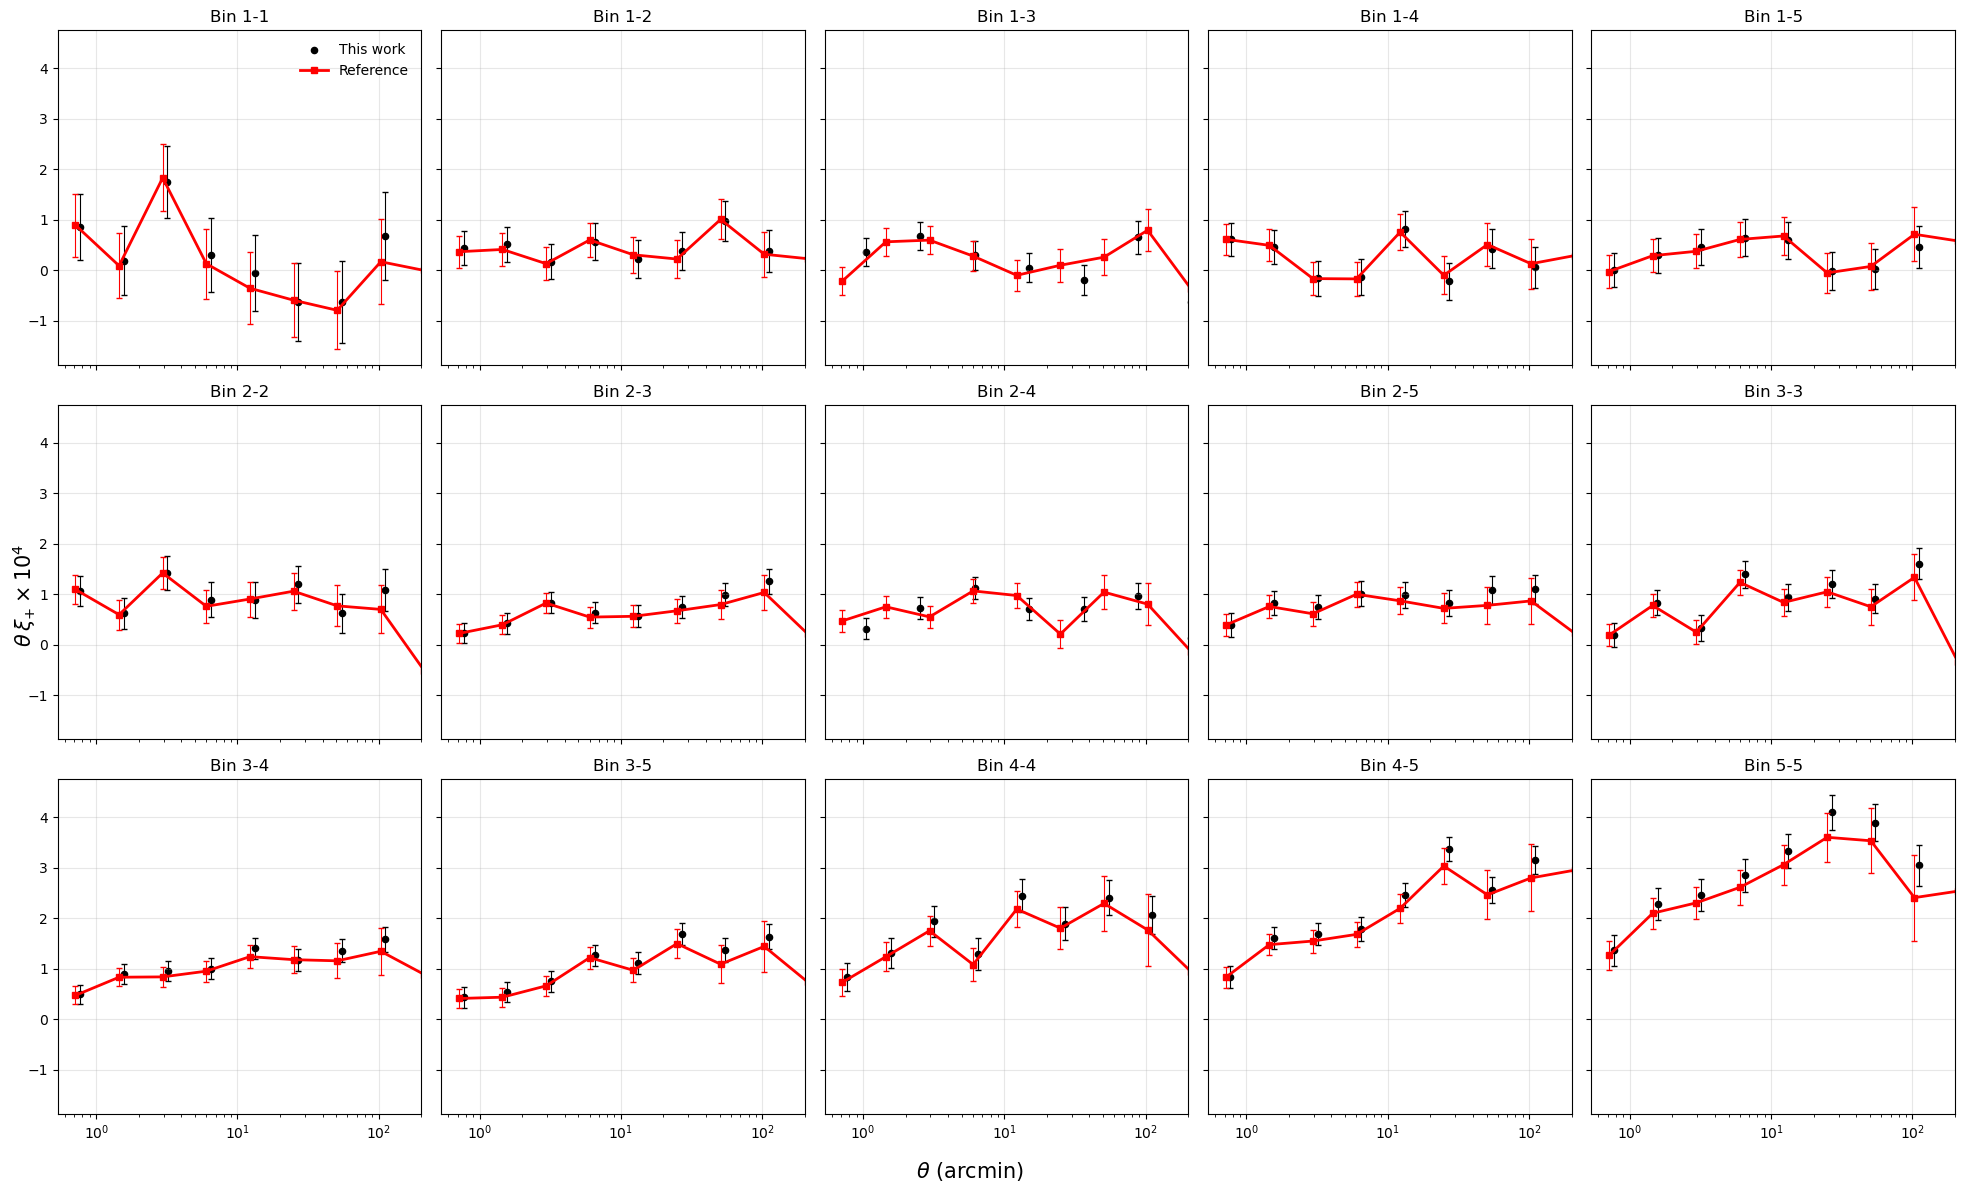

In [96]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

bin_pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

m_pairs = [
    (m_1,m_1), (m_1,m_2), (m_1,m_3), (m_1,m_4), (m_1,m_5),
    (m_2,m_2), (m_2,m_3), (m_2,m_4), (m_2,m_5),
    (m_3,m_3), (m_3,m_4), (m_3,m_5),
    (m_4,m_4), (m_4,m_5),
    (m_5,m_5)
]

scale = 1e4
n_theta = 9

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for c, (ax, gg, lab, (b1, b2), (m1, m2)) in enumerate(
    zip(axes, ggs, labels, bin_pairs, m_pairs)
):

    # -------------------------
    # Multiplicative bias correction
    # -------------------------
    m_corr = (1.0 + m1) * (1.0 + m2)

    # -------------------------
    # This work
    # -------------------------
    r = np.exp(gg.meanlogr)

    xip = scale * gg.xip / m_corr
    sig = scale * np.sqrt(gg.varxip) / m_corr

    ax.scatter(
        r,
        r * xip,
        color='black',
        s=20,
        marker='o',
        label='This work' if c == 0 else None
    )

    ax.errorbar(
        r,
        r * xip,
        yerr=r * sig,
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    ref = data_ref_xip[
        (data_ref_xip['BIN1'] == b1) &
        (data_ref_xip['BIN2'] == b2)
    ]

    start = c * n_theta
    end = (c + 1) * n_theta

    # sqrt because covariance diagonal = variance
    ref_err = np.sqrt(ref_errors_xip[start:end])

    ax.plot(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        color='red',
        lw=2,
        marker='s',
        ms=4,
        label='Reference' if c == 0 else None
    )

    ax.errorbar(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        yerr=scale * ref['ANG'] * ref_err,
        fmt='none',
        ecolor='red',
        elinewidth=0.8,
        capsize=2
    )

    ax.set_xscale('log')
    ax.set_xlim(-2.5, 200)
    # ax.set_ylim(-4, 4)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{+}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("xip_comparison.png", dpi=300)
plt.show()

/tmp/ipykernel_4055994/3255915390.py:109: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-2.5, 200)


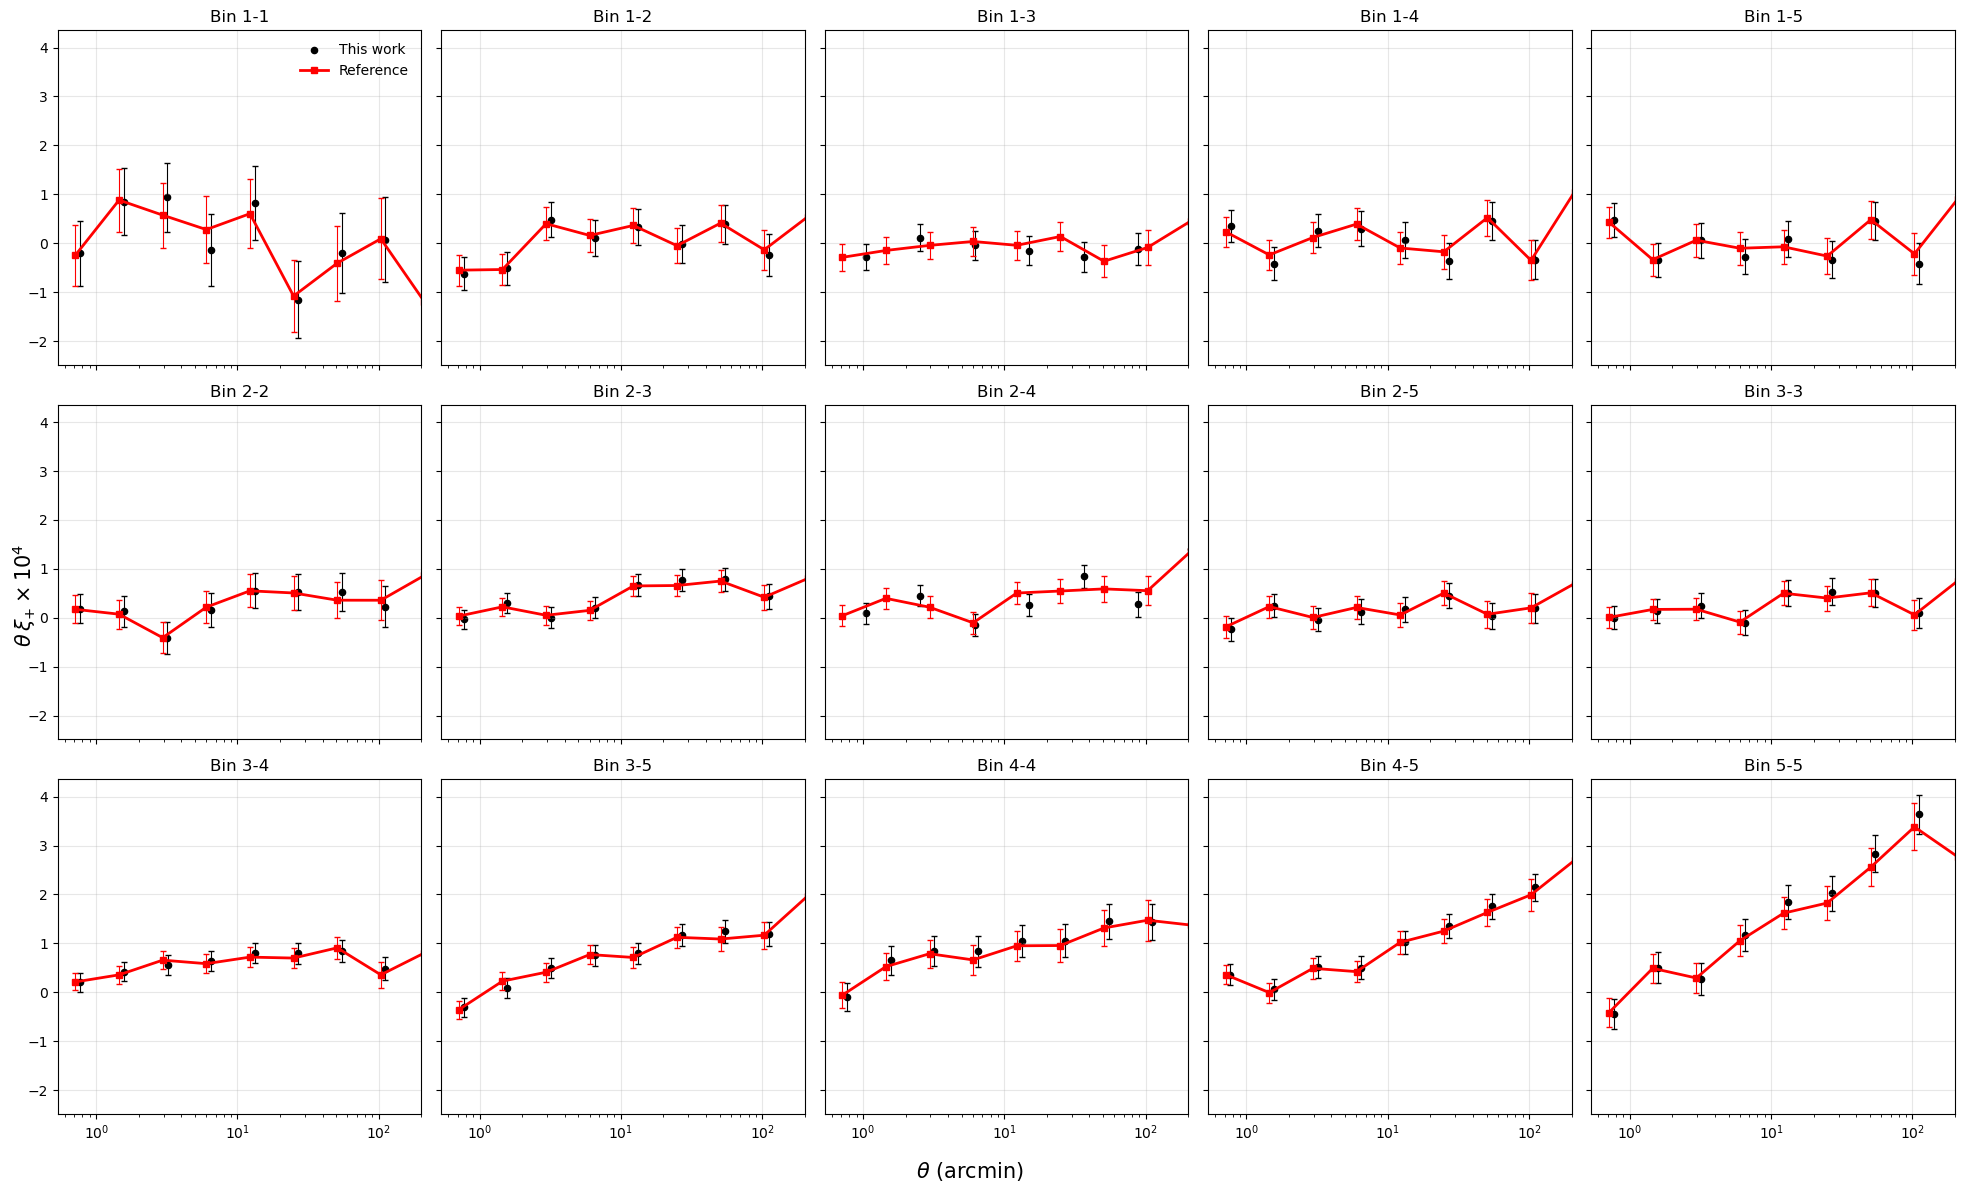

In [95]:
import numpy as np
import matplotlib.pyplot as plt

ggs = [
    gg11, gg12, gg13, gg14, gg15,
    gg22, gg23, gg24, gg25, gg33,
    gg34, gg35, gg44, gg45, gg55
]

labels = [
    "1-1", "1-2", "1-3", "1-4", "1-5",
    "2-2", "2-3", "2-4", "2-5", "3-3",
    "3-4", "3-5", "4-4", "4-5", "5-5"
]

bin_pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

m_pairs = [
    (m_1,m_1), (m_1,m_2), (m_1,m_3), (m_1,m_4), (m_1,m_5),
    (m_2,m_2), (m_2,m_3), (m_2,m_4), (m_2,m_5),
    (m_3,m_3), (m_3,m_4), (m_3,m_5),
    (m_4,m_4), (m_4,m_5),
    (m_5,m_5)
]

scale = 1e4
n_theta = 9

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.ravel()

for c, (ax, gg, lab, (b1, b2), (m1, m2)) in enumerate(
    zip(axes, ggs, labels, bin_pairs, m_pairs)
):

    # -------------------------
    # Multiplicative bias correction
    # -------------------------
    m_corr = (1.0 + m1) * (1.0 + m2)

    # -------------------------
    # This work
    # -------------------------
    r = np.exp(gg.meanlogr)

    xim = scale * gg.xim / m_corr
    sig = scale * np.sqrt(gg.varxim) / m_corr

    ax.scatter(
        r,
        r * xim,
        color='black',
        s=20,
        marker='o',
        label='This work' if c == 0 else None
    )

    ax.errorbar(
        r,
        r * xim,
        yerr=r * sig,
        fmt='none',
        ecolor='black',
        elinewidth=0.8,
        capsize=2
    )

    # -------------------------
    # Reference
    # -------------------------
    ref = data_ref_xim[
        (data_ref_xim['BIN1'] == b1) &
        (data_ref_xim['BIN2'] == b2)
    ]

    start = c * n_theta
    end = (c + 1) * n_theta

    # sqrt because covariance diagonal = variance
    ref_err = np.sqrt(ref_errors_xim[start:end])

    ax.plot(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        color='red',
        lw=2,
        marker='s',
        ms=4,
        label='Reference' if c == 0 else None
    )

    ax.errorbar(
        ref['ANG'],
        scale * ref['ANG'] * ref['VALUE'],
        yerr=scale * ref['ANG'] * ref_err,
        fmt='none',
        ecolor='red',
        elinewidth=0.8,
        capsize=2
    )

    ax.set_xscale('log')
    ax.set_xlim(-2.5, 200)
    # ax.set_ylim(-4, 4)
    ax.set_title(f'Bin {lab}', fontsize=12)
    ax.grid(alpha=0.3)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=15)
fig.supylabel(r'$\theta\,\xi_{+}\times10^{4}$', fontsize=15)

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("xim_comparison.png", dpi=300)
plt.show()